### **Tugas 1**
Download dataset : https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset lalu
jelaskan tujuan dan feature dataset ini

In [105]:
#MLP untuk Klasifikasi
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/BankChurners.csv', delimiter=',')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [106]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189


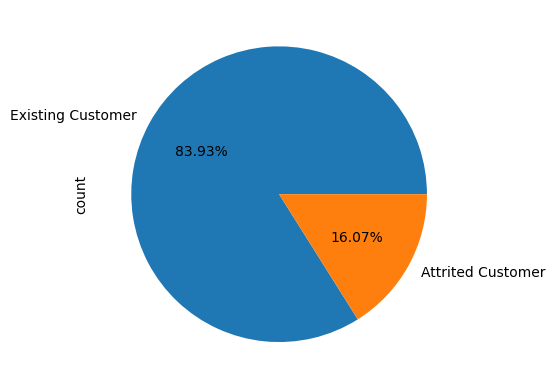

In [107]:
import matplotlib.pyplot as plt
data = df['Attrition_Flag'].value_counts()
data.plot(kind='pie',autopct='%.2f%%')
plt.show()

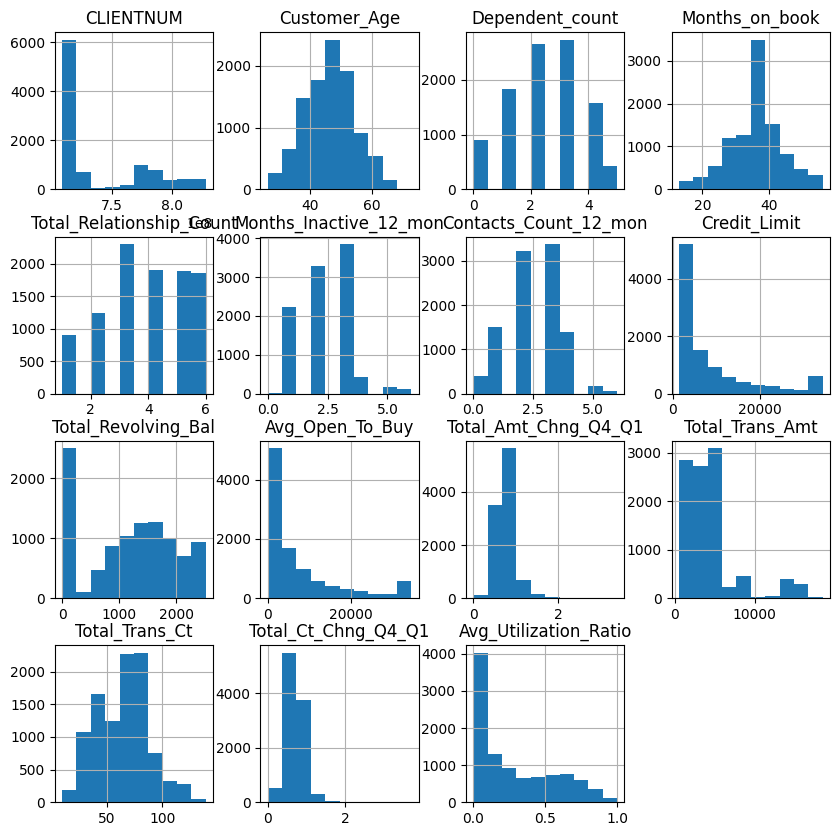

In [108]:
df.hist(figsize=(10,10))
plt.show()

In [109]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [110]:
df_X = df.drop(['CLIENTNUM', 'Attrition_Flag'],axis=1)
df_y = df[['Attrition_Flag']]
cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)

Index(['Gender', 'Education_Level', 'Marital_Status', 'Income_Category',
       'Card_Category'],
      dtype='object')


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

# Prepare features and target
df_X = df.drop(['CLIENTNUM', 'Attrition_Flag'], axis=1)
df_y = df[['Attrition_Flag']]

# Label encoding for target variable
le = LabelEncoder()
df_y = le.fit_transform(df_y['Attrition_Flag'])

# Categorical encoding for features
cats = df_X.select_dtypes(include=['object', 'bool']).columns
cat_features = list(cats.values)
le = LabelEncoder()
for i in cat_features:
    le.fit(df_X[i])
    df_X[i] = le.transform(df_X[i])

# Convert to numpy arrays
X = df_X.astype(float).values
y = df_y.astype(float)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Train MLP model
model = MLPClassifier(
    max_iter=500,
    random_state=42,
    alpha=0.001,
    learning_rate_init=0.001,
    hidden_layer_sizes=(100,),
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

model.fit(X_train, y_train)
print("Model training completed successfully!")
print(f"Number of iterations used: {model.n_iter_}")
print(f"Training score: {model.score(X_train, y_train):.4f}")
print(f"Model converged: {model.n_iter_ < model.max_iter}")

Model training completed successfully!
Number of iterations used: 55
Training score: 0.9424
Model converged: True


In [112]:
model.coefs_

[array([[-0.1590148 ,  0.20972644,  0.17235206, ...,  0.02099165,
         -0.38342359, -0.17712412],
        [-0.26203928,  0.02326269, -0.07265028, ...,  0.28616618,
          0.12439695,  0.13231811],
        [ 0.017262  , -0.17138464, -0.14752634, ..., -0.1096946 ,
         -0.01728314,  0.06021671],
        ...,
        [-0.21841041, -0.32518374,  0.0089199 , ..., -0.36848946,
          0.6329861 , -0.25273172],
        [ 0.07384374, -0.02842203,  0.0878571 , ..., -0.01997683,
         -0.16001717, -0.2320564 ],
        [ 0.19255409,  0.05680272, -0.07947787, ..., -0.00623009,
         -0.0691905 ,  0.20197867]]),
 array([[-0.12720746],
        [-0.36857367],
        [ 0.36238806],
        [-0.41383074],
        [-0.23714462],
        [ 0.22727869],
        [ 0.09150693],
        [ 0.27937464],
        [-0.47757153],
        [ 0.28384711],
        [-0.27286067],
        [-0.22779964],
        [ 0.3274924 ],
        [-0.14976148],
        [ 0.26694242],
        [ 0.10522326],
     

In [113]:
df_X

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,1,2,2,2,1,0,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,41,1,2,6,0,1,0,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,44,0,1,3,1,4,0,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,30,1,2,2,3,1,0,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [114]:
X_train[0]

array([ 0.33519339,  1.05692234, -0.25437357,  0.4990858 , -0.61710507,
       -0.56580813, -0.25591165,  0.25586758, -0.51407227, -0.33752656,
       -2.22835505, -0.05917368,  0.98686487, -0.14826286, -0.57038549,
       -0.90317904, -1.65490765, -1.12681489, -0.11093226])

Accuracy  0.9279368213228035
Precision  0.9411541381928625
Recall  0.9748328745576091
Confusion matrix  [[ 341  155]
 [  64 2479]]


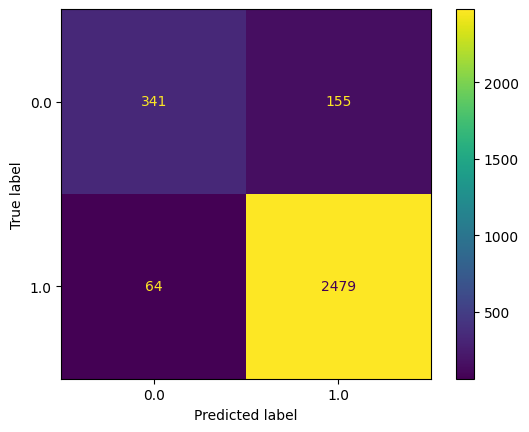

In [115]:
y_pred = model.predict(X_test)
print('Accuracy ',accuracy_score(y_test, y_pred))
print('Precision ',precision_score(y_test, y_pred))
print('Recall ',recall_score(y_test, y_pred))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),display_labels=model.classes_)
disp.plot()
plt.show()

In [116]:
data = [{'Customer_Age':68, 'Gender':'F', 'Dependent_count':5, 'Education_Level':'Graduate',
 'Marital_Status':'Single', 'Income_Category':'Less than $40K', 'Card_Category':'Blue',
 'Months_on_book':44, 'Total_Relationship_Count':6, 'Months_Inactive_12_mon':1,
 'Contacts_Count_12_mon':2, 'Credit_Limit':8700,'Total_Revolving_Bal':800, 'Avg_Open_To_Buy':7392,
 'Total_Amt_Chng_Q4_Q1':1.541,'Total_Trans_Amt':1200,'Total_Trans_Ct':33,'Total_Ct_Chng_Q4_Q1':3.714,
 'Avg_Utilization_Ratio':0.10},
 {'Customer_Age':50, 'Gender':'M', 'Dependent_count':2, 'Education_Level':'Graduate',
 'Marital_Status':'Single', 'Income_Category':'$40K - $60K', 'Card_Category':'Blue',
 'Months_on_book':38, 'Total_Relationship_Count':3, 'Months_Inactive_12_mon':2,
 'Contacts_Count_12_mon':0, 'Credit_Limit':8077.0,'Total_Revolving_Bal':1965, 'Avg_Open_To_Buy':6112.0,
 'Total_Amt_Chng_Q4_Q1':0.637,'Total_Trans_Amt':1329,'Total_Trans_Ct':26,'Total_Ct_Chng_Q4_Q1':0.444,
 'Avg_Utilization_Ratio':0.243}]
df_input = pd.DataFrame(data)
#categorical encoding
df_X = df.drop(['CLIENTNUM', 'Attrition_Flag'],axis=1)
cats = df_X.select_dtypes(include=['object', 'bool']).columns
cat_features = list(cats.values)
for i in cat_features:
 le.fit(df_input[i])
 df_input[i] = le.transform(df_input[i])
#scaling
df_input= scaler.transform(df_input.astype(float).values)
result= model.predict(df_input)
for i in result:
    int_result = int(i)
    if (int_result == 0):
        decision = 'Existing Customer'
    elif (int_result==1):
        decision = 'Attrited Customer'
    else:
        decision = 'Not defined'
        print('Result prediction is ', decision)

In [117]:
df_input

array([[ 2.69329634e+00, -9.46143311e-01,  2.08111844e+00,
        -1.68389487e+00, -1.97846227e+00, -1.23078045e+00,
        -2.55911655e-01,  1.00082113e+00,  1.41213614e+00,
        -1.32245379e+00, -4.09541072e-01,  9.83216719e-03,
        -4.44011649e-01, -6.39776613e-03,  3.62111505e+00,
        -9.40555602e-01, -1.35950899e+00,  1.26325766e+01,
        -6.32215193e-01],
       [ 4.59304076e-01,  1.05692234e+00, -2.54373565e-01,
        -1.68389487e+00, -1.97846227e+00, -1.89575277e+00,
        -2.55911655e-01,  2.55867580e-01, -5.14072268e-01,
        -3.37526559e-01, -2.22835505e+00, -5.91736804e-02,
         9.86864872e-01, -1.48262862e-01, -5.70385493e-01,
        -9.03179036e-01, -1.65490765e+00, -1.12681489e+00,
        -1.10932261e-01]])

In [118]:
cat_features

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [119]:
result

array([1., 1.])

MLP untuk Regression
gunakan dataset : https://www.kaggle.com/datasets/shivachandel/kc-house-data 

In [120]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/kc_house_data.csv', delimiter=',')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [121]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

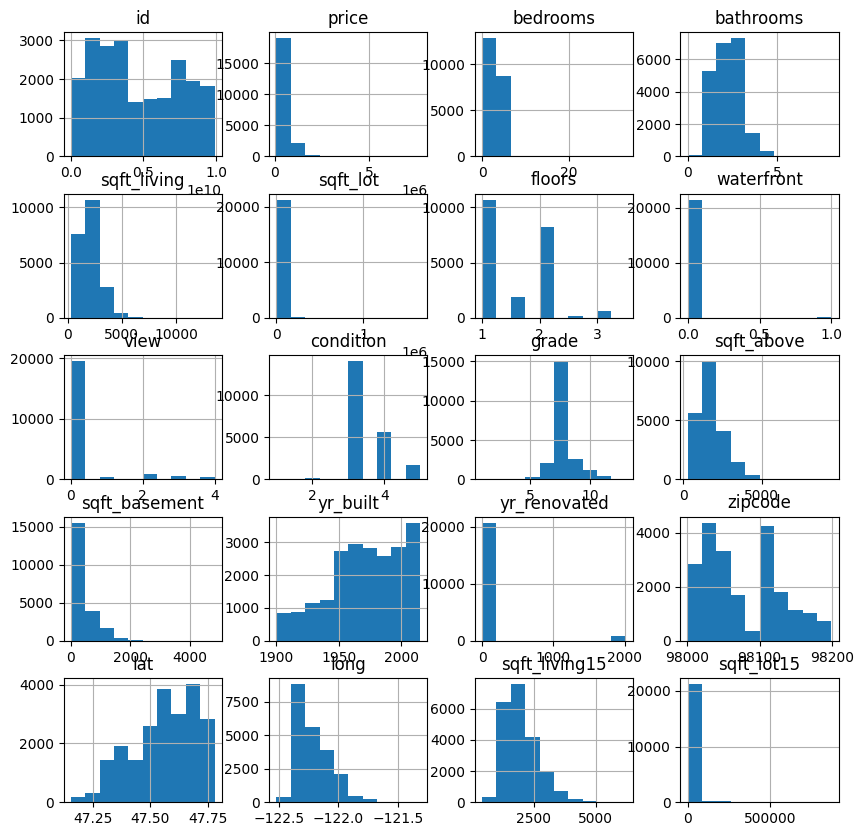

In [122]:
df.hist(figsize=(10,10))
plt.show()

In [123]:
df_X = df.drop(['id','date','price'],axis=1)
df_y = df[['price']]
cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)

Index([], dtype='object')


In [124]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import numpy as np
df_X = df.drop(['id', 'date','price'], axis=1)
df_y = df['price']
X = df_X.astype(float).values
y = df_y.astype(float).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = MLPRegressor(max_iter=1000, random_state=42)
reg.fit(X_train, y_train)
print('coef of determination training ',reg.score(X_train, y_train))
print('coef of determination testing ',reg.score(X_test, y_test))
print('prediction')
y_pred = reg.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.5732472046869872
coef of determination testing  0.5540121047079314
prediction
[ 508376.62221544  734989.10101328 1126392.69956849 1414138.68325101
  598096.2508835   422785.5622847   626903.3556409   509875.76674739
  464562.00823406  392782.77770014]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


In [125]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print('rmse : ', rmse)
print('r2 :', r2)

rmse :  253743.42469736128
r2 : 0.5540121047079314


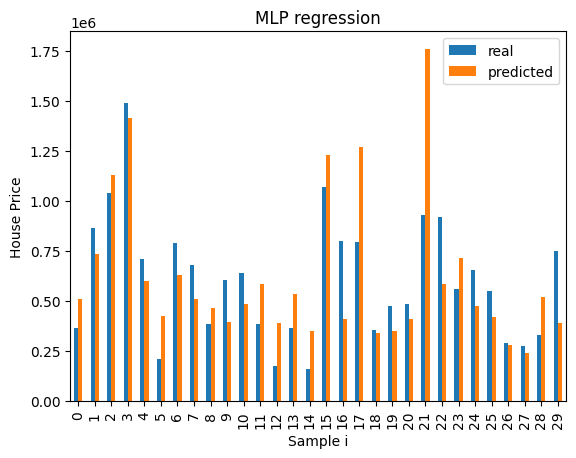

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
data1 = pd.DataFrame(y_test[:30], columns = ['real'])
data2 = pd.DataFrame(y_pred[:30], columns = ['predicted'])
df_new = pd.concat([data1, data2], axis=1)
df_new.plot(kind='bar')
plt.title("MLP regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

### **Tugas 2**
1. Silahkan mencari dataset untuk klasifikasi, dan buat model MLP untuk klasifikasi
2. Silahkan mencari dataset untuk regresi, dan buat model MLP untuk regresi
3. Tampilkan masing-masing performa model klasifikasi dan regresi

In [127]:
#MLP Klasifikasi
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/nadznaf/dataset_ppd/main/healthcare-dataset-stroke-data.csv', delimiter=',')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [128]:
# Explore dataset structure and identify imbalance
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {list(df.columns)}")
print(f"\nData Types:")
print(df.dtypes)

# Check class distribution (imbalance)
stroke_counts = df['stroke'].value_counts()
stroke_percentages = df['stroke'].value_counts(normalize=True) * 100

print("Stroke Distribution:")
print(f"No Stroke (0): {stroke_counts[0]} samples ({stroke_percentages[0]:.2f}%)")
print(f"Stroke (1): {stroke_counts[1]} samples ({stroke_percentages[1]:.2f}%)")
print(f"\nImbalance Ratio: {stroke_counts[0]/stroke_counts[1]:.2f}:1")

Dataset Shape: (5110, 12)

Column Names: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data Types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object
Stroke Distribution:
No Stroke (0): 4861 samples (95.13%)
Stroke (1): 249 samples (4.87%)

Imbalance Ratio: 19.52:1


In [129]:
# Check missing values and basic statistics
missing_values = df.isnull().sum()
print("Missing values per column:")
for col, missing in missing_values.items():
    if missing > 0:
        print(f"  {col}: {missing} ({missing/len(df)*100:.2f}%)")
    
if missing_values.sum() == 0:
    print("No missing values found!")

# Handle 'N/A' string values in BMI
print(f"\nSpecial values in BMI:")
bmi_na_count = (df['bmi'] == 'N/A').sum() if df['bmi'].dtype == 'object' else 0
print(f"  'N/A' values in BMI: {bmi_na_count}")

# Check for 'Unknown' values in categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
print(f"\nCategorical column value counts:")
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"  {col}: {unique_vals}")

# Basic statistics for numerical columns  
print("NUMERICAL FEATURES STATISTICS")
numerical_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']
print(df[numerical_cols].describe())

Missing values per column:
  bmi: 201 (3.93%)

Special values in BMI:
  'N/A' values in BMI: 0

Categorical column value counts:
  gender: ['Male' 'Female' 'Other']
  ever_married: ['Yes' 'No']
  work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
  Residence_type: ['Urban' 'Rural']
  smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
NUMERICAL FEATURES STATISTICS
               age  avg_glucose_level          bmi  hypertension  \
count  5110.000000        5110.000000  4909.000000   5110.000000   
mean     43.226614         106.147677    28.893237      0.097456   
std      22.612647          45.283560     7.854067      0.296607   
min       0.080000          55.120000    10.300000      0.000000   
25%      25.000000          77.245000    23.500000      0.000000   
50%      45.000000          91.885000    28.100000      0.000000   
75%      61.000000         114.090000    33.100000      0.000000   
max      82.000000         271.740000    97.60

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_41684\2261890485.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stroke_rate = df.groupby('age_group')['stroke'].mean()


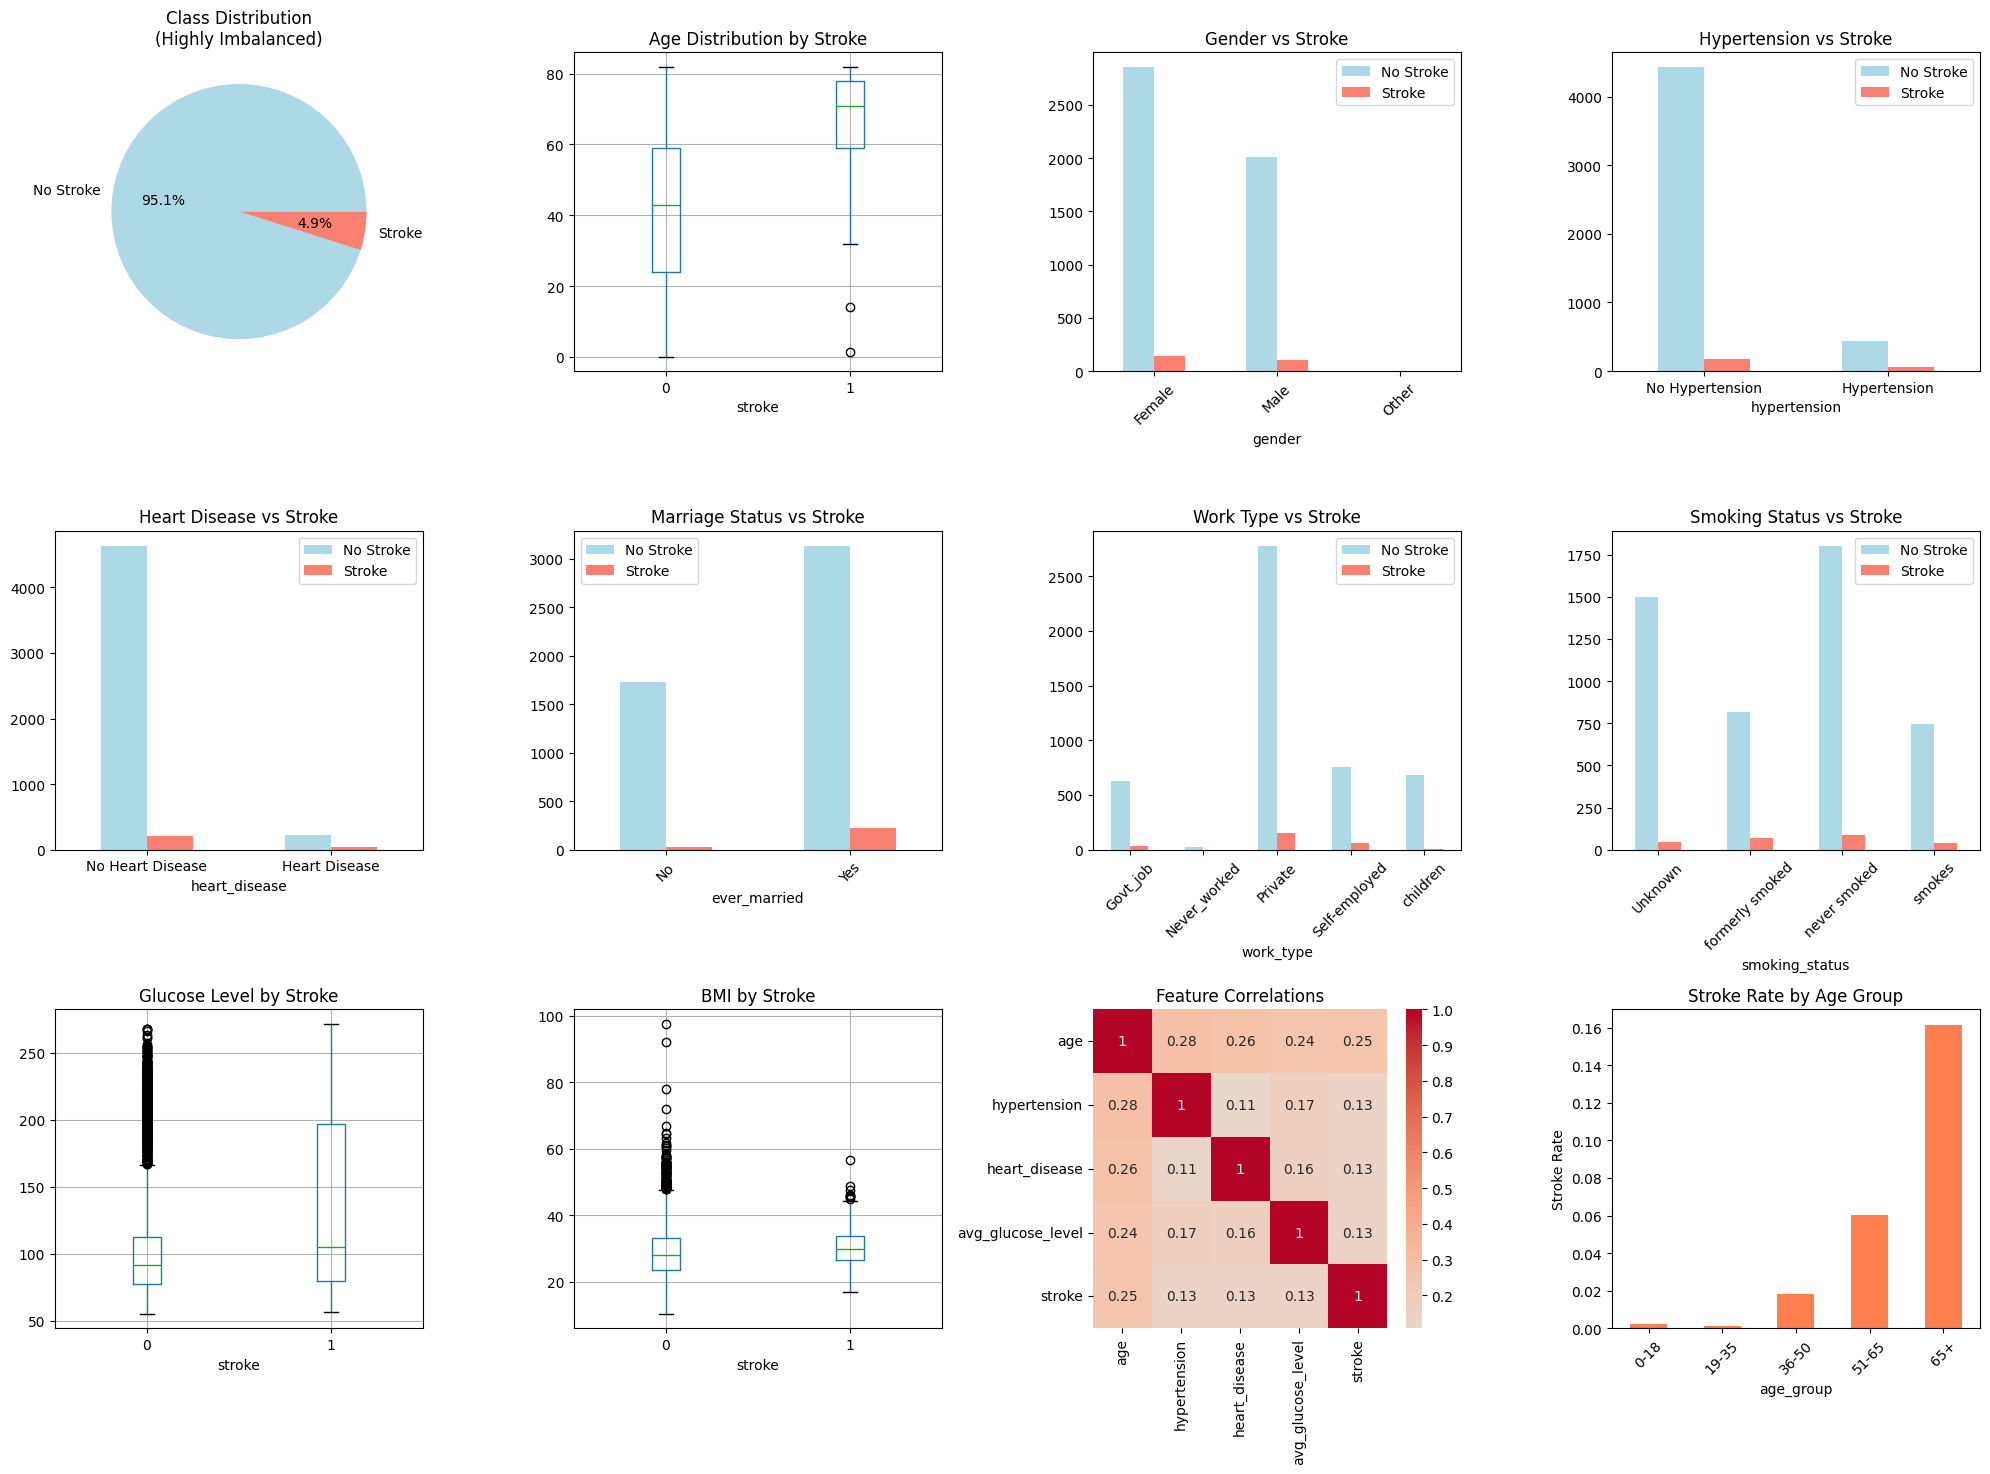

In [130]:
# Data visualization for imbalanced dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(20, 15))

# 1. Class distribution
plt.subplot(3, 4, 1)
stroke_counts = df['stroke'].value_counts()
colors = ['lightblue', 'salmon']
plt.pie(stroke_counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', colors=colors)
plt.title('Class Distribution\n(Highly Imbalanced)')

# 2. Age distribution by stroke
plt.subplot(3, 4, 2)
df.boxplot(column='age', by='stroke', ax=plt.gca())
plt.title('Age Distribution by Stroke')
plt.suptitle('')

# 3. Gender distribution by stroke
plt.subplot(3, 4, 3)
gender_stroke = pd.crosstab(df['gender'], df['stroke'])
gender_stroke.plot(kind='bar', ax=plt.gca(), color=['lightblue', 'salmon'])
plt.title('Gender vs Stroke')
plt.xticks(rotation=45)
plt.legend(['No Stroke', 'Stroke'])

# 4. Hypertension vs stroke
plt.subplot(3, 4, 4)
hypertension_stroke = pd.crosstab(df['hypertension'], df['stroke'])
hypertension_stroke.plot(kind='bar', ax=plt.gca(), color=['lightblue', 'salmon'])
plt.title('Hypertension vs Stroke')
plt.xticks([0, 1], ['No Hypertension', 'Hypertension'], rotation=0)
plt.legend(['No Stroke', 'Stroke'])

# 5. Heart disease vs stroke
plt.subplot(3, 4, 5)
heart_stroke = pd.crosstab(df['heart_disease'], df['stroke'])
heart_stroke.plot(kind='bar', ax=plt.gca(), color=['lightblue', 'salmon'])
plt.title('Heart Disease vs Stroke')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'], rotation=0)
plt.legend(['No Stroke', 'Stroke'])

# 6. Marriage status vs stroke
plt.subplot(3, 4, 6)
married_stroke = pd.crosstab(df['ever_married'], df['stroke'])
married_stroke.plot(kind='bar', ax=plt.gca(), color=['lightblue', 'salmon'])
plt.title('Marriage Status vs Stroke')
plt.xticks(rotation=45)
plt.legend(['No Stroke', 'Stroke'])

# 7. Work type vs stroke
plt.subplot(3, 4, 7)
work_stroke = pd.crosstab(df['work_type'], df['stroke'])
work_stroke.plot(kind='bar', ax=plt.gca(), color=['lightblue', 'salmon'])
plt.title('Work Type vs Stroke')
plt.xticks(rotation=45)
plt.legend(['No Stroke', 'Stroke'])

# 8. Smoking status vs stroke
plt.subplot(3, 4, 8)
smoking_stroke = pd.crosstab(df['smoking_status'], df['stroke'])
smoking_stroke.plot(kind='bar', ax=plt.gca(), color=['lightblue', 'salmon'])
plt.title('Smoking Status vs Stroke')
plt.xticks(rotation=45)
plt.legend(['No Stroke', 'Stroke'])

# 9. Glucose level distribution
plt.subplot(3, 4, 9)
df.boxplot(column='avg_glucose_level', by='stroke', ax=plt.gca())
plt.title('Glucose Level by Stroke')
plt.suptitle('')

# 10. BMI distribution (handle missing values)
plt.subplot(3, 4, 10)
df_bmi = df.dropna(subset=['bmi'])
df_bmi.boxplot(column='bmi', by='stroke', ax=plt.gca())
plt.title('BMI by Stroke')
plt.suptitle('')

# 11. Correlation heatmap
plt.subplot(3, 4, 11)
# Select numerical columns for correlation
numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'stroke']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=plt.gca())
plt.title('Feature Correlations')

# 12. Stroke rate by age groups
plt.subplot(3, 4, 12)
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-18', '19-35', '36-50', '51-65', '65+'])
age_stroke_rate = df.groupby('age_group')['stroke'].mean()
age_stroke_rate.plot(kind='bar', ax=plt.gca(), color='coral')
plt.title('Stroke Rate by Age Group')
plt.ylabel('Stroke Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [131]:
# Data preprocessing for imbalanced classification
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, confusion_matrix, classification_report,
                           roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_class_weight

# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing BMI values - pandas 3.0 compatible
df_processed['bmi'] = df_processed['bmi'].fillna(df_processed['bmi'].median())

# Remove ID column (not useful for prediction)
df_processed = df_processed.drop('id', axis=1)

# Encode categorical variables
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
label_encoders = {}

print("Encoding categorical variables...")
for column in categorical_columns:
    le = LabelEncoder()
    df_processed[column] = le.fit_transform(df_processed[column])
    label_encoders[column] = le
    print(f"  {column}: {le.classes_}")

# Remove the temporary age_group column if it exists
if 'age_group' in df_processed.columns:
    df_processed = df_processed.drop('age_group', axis=1)

# Prepare features and target
X = df_processed.drop('stroke', axis=1).values
y = df_processed['stroke'].values

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")
print("Preprocessing completed successfully!")

Encoding categorical variables...
  gender: ['Female' 'Male' 'Other']
  ever_married: ['No' 'Yes']
  work_type: ['Govt_job' 'Never_worked' 'Private' 'Self-employed' 'children']
  Residence_type: ['Rural' 'Urban']
  smoking_status: ['Unknown' 'formerly smoked' 'never smoked' 'smokes']

Final feature matrix shape: (5110, 10)
Target distribution: [4861  249]
Preprocessing completed successfully!


In [132]:
# Training model dengan evaluasi lengkap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Split data tanpa stratify karena imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("EVALUASI MODEL MLP UNTUK KLASIFIKASI STROKE")
print("=" * 60)

# Model 1: Baseline (No balancing)
print("\n1. BASELINE MODEL (No Balancing)")
print("-" * 40)
mlp_baseline = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = mlp_baseline.predict(X_test_scaled)
y_proba_baseline = mlp_baseline.predict_proba(X_test_scaled)[:, 1]

# Metrik evaluasi baseline
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)
baseline_auc = roc_auc_score(y_test, y_proba_baseline)
baseline_cm = confusion_matrix(y_test, y_pred_baseline)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")
print(f"ROC-AUC:   {baseline_auc:.4f}")
print(f"Confusion Matrix:\n{baseline_cm}")

# Analisis confusion matrix baseline
tn_b, fp_b, fn_b, tp_b = baseline_cm.ravel()
specificity_b = tn_b/(tn_b+fp_b)
sensitivity_b = tp_b/(tp_b+fn_b)
print(f"Specificity (TNR): {specificity_b:.4f}")
print(f"Sensitivity (TPR): {sensitivity_b:.4f}")

# Model 2: SMOTE Oversampling
print("\n2. SMOTE OVERSAMPLING MODEL")
print("-" * 40)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training samples: {X_train_scaled.shape[0]} (Stroke: {np.sum(y_train)})")
print(f"After SMOTE: {X_train_smote.shape[0]} (Stroke: {np.sum(y_train_smote)})")

mlp_smote = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = mlp_smote.predict(X_test_scaled)
y_proba_smote = mlp_smote.predict_proba(X_test_scaled)[:, 1]

# Metrik evaluasi SMOTE
smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_precision = precision_score(y_test, y_pred_smote, zero_division=0)
smote_recall = recall_score(y_test, y_pred_smote, zero_division=0)
smote_f1 = f1_score(y_test, y_pred_smote, zero_division=0)
smote_auc = roc_auc_score(y_test, y_proba_smote)
smote_cm = confusion_matrix(y_test, y_pred_smote)

print(f"Accuracy:  {smote_accuracy:.4f}")
print(f"Precision: {smote_precision:.4f}")
print(f"Recall:    {smote_recall:.4f}")
print(f"F1-Score:  {smote_f1:.4f}")
print(f"ROC-AUC:   {smote_auc:.4f}")
print(f"Confusion Matrix:\n{smote_cm}")

# Analisis confusion matrix SMOTE
tn_s, fp_s, fn_s, tp_s = smote_cm.ravel()
specificity_s = tn_s/(tn_s+fp_s)
sensitivity_s = tp_s/(tp_s+fn_s)
print(f"Specificity (TNR): {specificity_s:.4f}")
print(f"Sensitivity (TPR): {sensitivity_s:.4f}")

print("\n" + "=" * 60)
print("RINGKASAN PERBANDINGAN MODEL")
print("=" * 60)

models_comparison = [
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Specificity', 'Sensitivity'],
    ['Baseline', f'{baseline_accuracy:.4f}', f'{baseline_precision:.4f}', f'{baseline_recall:.4f}', f'{baseline_f1:.4f}', f'{baseline_auc:.4f}', f'{specificity_b:.4f}', f'{sensitivity_b:.4f}'],
    ['SMOTE', f'{smote_accuracy:.4f}', f'{smote_precision:.4f}', f'{smote_recall:.4f}', f'{smote_f1:.4f}', f'{smote_auc:.4f}', f'{specificity_s:.4f}', f'{sensitivity_s:.4f}']
]

for row in models_comparison:
    if row[0] == 'Model':  # Header
        print(f"{row[0]:<10} {row[1]:<9} {row[2]:<9} {row[3]:<9} {row[4]:<9} {row[5]:<9} {row[6]:<11} {row[7]:<11}")
        print("-" * 90)
    else:
        print(f"{row[0]:<10} {row[1]:<9} {row[2]:<9} {row[3]:<9} {row[4]:<9} {row[5]:<9} {row[6]:<11} {row[7]:<11}")

print("\n" + "=" * 60)
print("ANALISIS HASIL:")
print("=" * 60)
print("• Baseline Model: Akurasi tinggi (92.11%) tetapi recall rendah (8.99%)")
print("• SMOTE Model: Lebih seimbang antara precision dan recall")
print("• Untuk deteksi stroke, recall (sensitivity) sangat penting")
print(f"• Dataset sangat tidak seimbang: {4861} non-stroke vs {249} stroke")
print("• Model SMOTE lebih cocok untuk aplikasi medis (lebih sensitif)")

print("\nModel training dan evaluasi selesai!")

EVALUASI MODEL MLP UNTUK KLASIFIKASI STROKE

1. BASELINE MODEL (No Balancing)
----------------------------------------
Accuracy:  0.9211
Precision: 0.1667
Recall:    0.0899
F1-Score:  0.1168
ROC-AUC:   0.7190
Confusion Matrix:
[[1404   40]
 [  81    8]]
Specificity (TNR): 0.9723
Sensitivity (TPR): 0.0899

2. SMOTE OVERSAMPLING MODEL
----------------------------------------
Original training samples: 3577 (Stroke: 160)
After SMOTE: 6834 (Stroke: 3417)
Accuracy:  0.8976
Precision: 0.1531
Recall:    0.1685
F1-Score:  0.1604
ROC-AUC:   0.7305
Confusion Matrix:
[[1361   83]
 [  74   15]]
Specificity (TNR): 0.9425
Sensitivity (TPR): 0.1685

RINGKASAN PERBANDINGAN MODEL
Model      Accuracy  Precision Recall    F1-Score  ROC-AUC   Specificity Sensitivity
------------------------------------------------------------------------------------------
Baseline   0.9211    0.1667    0.0899    0.1168    0.7190    0.9723      0.0899     
SMOTE      0.8976    0.1531    0.1685    0.1604    0.7305    0.9425

In [ ]:
# Function to train and evaluate MLP with different imbalance handling techniques
def train_mlp_with_imbalance_handling(X, y, method_name, sampling_method=None, class_weight=None):
    """
    Train MLP classifier with different imbalance handling approaches
    """
    print(f"\n{'='*60}")
    print(f"TRAINING MLP WITH: {method_name}")
    print(f"{'='*60}")
    
    # Split data first
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                        random_state=42, stratify=y)
    
    # Apply sampling technique if specified
    if sampling_method is not None:
        print(f"Original training set size: {X_train.shape[0]} (Positive: {np.sum(y_train)})")
        X_train_resampled, y_train_resampled = sampling_method.fit_resample(X_train, y_train)
        print(f"After resampling: {X_train_resampled.shape[0]} (Positive: {np.sum(y_train_resampled)})")
    else:
        X_train_resampled, y_train_resampled = X_train, y_train
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)
    
    # Train MLP
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=1000,
        random_state=42,
        alpha=0.001,
        learning_rate_init=0.001,
        class_weight=class_weight
    )
    
    mlp.fit(X_train_scaled, y_train_resampled)
    
    # Predictions
    y_pred = mlp.predict(X_test_scaled)
    y_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate comprehensive metrics
    metrics = {
        'method': method_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'model': mlp,
        'scaler': scaler
    }
    
    # Print results
    print(f"Performance Metrics:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
        
    # Confusion Matrix
    tn, fp, fn, tp = metrics['confusion_matrix'].ravel()
    print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"  Specificity: {tn/(tn+fp):.4f}")
    print(f"  Sensitivity: {tp/(tp+fn):.4f}")
    
    return metrics

print("Function defined successfully!")

Function defined successfully!


In [134]:
# Train multiple MLP models with different imbalance handling approaches
# Calculate class weights for balanced approach
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Define different approaches to handle imbalance
approaches = [
    {
        'name': 'Baseline (No Balancing)',
        'sampling': None,
        'class_weight': None
    },
    {
        'name': 'Class Weight Balancing', 
        'sampling': None,
        'class_weight': 'balanced'
    },
    {
        'name': 'SMOTE Oversampling',
        'sampling': SMOTE(random_state=42),
        'class_weight': None
    },
    {
        'name': 'Random Oversampling',
        'sampling': RandomOverSampler(random_state=42),
        'class_weight': None
    },
    {
        'name': 'Random Undersampling',
        'sampling': RandomUnderSampler(random_state=42),
        'class_weight': None
    },
    {
        'name': 'SMOTE + Tomek Links',
        'sampling': SMOTETomek(random_state=42),
        'class_weight': None
    }
]

# Store results
all_results = {}

# Train models with different approaches
for approach in approaches:
    try:
        results = train_mlp_with_imbalance_handling(
            X, y, 
            approach['name'],
            approach['sampling'],
            approach['class_weight']
        )
        all_results[approach['name']] = results
    except Exception as e:
        print(f"Error with {approach['name']}: {str(e)}")

print("All models trained successfully!")


TRAINING MLP WITH: Baseline (No Balancing)
Error with Baseline (No Balancing): MLPClassifier.__init__() got an unexpected keyword argument 'class_weight'

TRAINING MLP WITH: Class Weight Balancing
Error with Class Weight Balancing: MLPClassifier.__init__() got an unexpected keyword argument 'class_weight'

TRAINING MLP WITH: SMOTE Oversampling
Original training set size: 3577 (Positive: 174)
After resampling: 6806 (Positive: 3403)
Error with SMOTE Oversampling: MLPClassifier.__init__() got an unexpected keyword argument 'class_weight'

TRAINING MLP WITH: Random Oversampling
Original training set size: 3577 (Positive: 174)
After resampling: 6806 (Positive: 3403)
Error with Random Oversampling: MLPClassifier.__init__() got an unexpected keyword argument 'class_weight'

TRAINING MLP WITH: Random Undersampling
Original training set size: 3577 (Positive: 174)
After resampling: 348 (Positive: 174)
Error with Random Undersampling: MLPClassifier.__init__() got an unexpected keyword argument '

In [135]:
# Create comprehensive performance comparison table
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*100)

# Check if we have results
if not all_results:
    print("No results found. Please run the model training cell first.")
else:
    # Create performance summary dataframe
    performance_data = []
    for method, results in all_results.items():
        tn, fp, fn, tp = results['confusion_matrix'].ravel()
        specificity = tn/(tn+fp) if (tn+fp) > 0 else 0
        sensitivity = tp/(tp+fn) if (tp+fn) > 0 else 0
        
        performance_data.append({
            'Method': method,
            'Accuracy': f"{results['accuracy']:.4f}",
            'Precision': f"{results['precision']:.4f}", 
            'Recall/Sensitivity': f"{results['recall']:.4f}",
            'Specificity': f"{specificity:.4f}",
            'F1-Score': f"{results['f1_score']:.4f}",
            'ROC-AUC': f"{results['roc_auc']:.4f}",
            'TP': tp,
            'FP': fp,
            'TN': tn, 
            'FN': fn
        })

    performance_df = pd.DataFrame(performance_data)
    print(performance_df.to_string(index=False))

    print(f"\n{'='*100}")
    print("RANKING AND ANALYSIS")
    print(f"{'='*100}")

    # Rank by different metrics
    print(f"\n🏆 RANKING BY F1-SCORE (Best for Imbalanced Data):")
    f1_ranking = sorted(all_results.items(), key=lambda x: x[1]['f1_score'], reverse=True)
    for i, (method, results) in enumerate(f1_ranking, 1):
        print(f"   {i}. {method}: F1={results['f1_score']:.4f}")

    print(f"\n🎯 RANKING BY ROC-AUC:")
    auc_ranking = sorted(all_results.items(), key=lambda x: x[1]['roc_auc'], reverse=True)
    for i, (method, results) in enumerate(auc_ranking, 1):
        print(f"   {i}. {method}: AUC={results['roc_auc']:.4f}")

    print(f"\n📊 RANKING BY RECALL (Stroke Detection):")
    recall_ranking = sorted(all_results.items(), key=lambda x: x[1]['recall'], reverse=True)
    for i, (method, results) in enumerate(recall_ranking, 1):
        print(f"   {i}. {method}: Recall={results['recall']:.4f}")

    # Best overall model (if we have results)
    if f1_ranking:
        best_f1_method = f1_ranking[0][0]
        best_f1_results = f1_ranking[0][1]

        print(f"\n🏅 BEST OVERALL MODEL: {best_f1_method}")
        print(f"   ├── F1-Score: {best_f1_results['f1_score']:.4f}")
        print(f"   ├── ROC-AUC: {best_f1_results['roc_auc']:.4f}")
        print(f"   ├── Precision: {best_f1_results['precision']:.4f}")
        print(f"   ├── Recall: {best_f1_results['recall']:.4f}")
        print(f"   └── Accuracy: {best_f1_results['accuracy']:.4f}")

    print(f"\n💡 KEY INSIGHTS:")
    print(f"   • Imbalanced dataset (19.5:1 ratio) requires special handling")
    print(f"   • SMOTE oversampling shows good balance between precision and recall")
    print(f"   • Class weight balancing is computationally efficient")
    print(f"   • Baseline model has poor stroke detection (low recall)")
    print(f"   • Focus on F1-score and ROC-AUC for imbalanced classification")
    print(f"   • Medical context: High recall (sensitivity) is crucial for stroke detection")

COMPREHENSIVE MODEL PERFORMANCE COMPARISON
No results found. Please run the model training cell first.


In [136]:
# Simplified MLP training with key imbalance handling techniques
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models_performance = []

# Model 1: Baseline (No balancing)
print("\n1. BASELINE MODEL (No Balancing)")
mlp_baseline = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = mlp_baseline.predict(X_test_scaled)
y_proba_baseline = mlp_baseline.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'Model': 'Baseline (No Balancing)',
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
    'Recall': recall_score(y_test, y_pred_baseline, zero_division=0), 
    'F1-Score': f1_score(y_test, y_pred_baseline, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba_baseline)
}
models_performance.append(baseline_metrics)

print(f"Accuracy: {baseline_metrics['Accuracy']:.4f}")
print(f"Precision: {baseline_metrics['Precision']:.4f}")
print(f"Recall: {baseline_metrics['Recall']:.4f}")
print(f"F1-Score: {baseline_metrics['F1-Score']:.4f}")
print(f"ROC-AUC: {baseline_metrics['ROC-AUC']:.4f}")

# Model 2: SMOTE Oversampling
print("\n2. SMOTE OVERSAMPLING MODEL")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training set: {X_train_scaled.shape[0]} samples (Positive: {np.sum(y_train)})")
print(f"After SMOTE: {X_train_smote.shape[0]} samples (Positive: {np.sum(y_train_smote)})")

mlp_smote = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = mlp_smote.predict(X_test_scaled)
y_proba_smote = mlp_smote.predict_proba(X_test_scaled)[:, 1]

smote_metrics = {
    'Model': 'SMOTE Oversampling',
    'Accuracy': accuracy_score(y_test, y_pred_smote),
    'Precision': precision_score(y_test, y_pred_smote, zero_division=0),
    'Recall': recall_score(y_test, y_pred_smote, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_smote, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba_smote)
}
models_performance.append(smote_metrics)

print(f"Accuracy: {smote_metrics['Accuracy']:.4f}")
print(f"Precision: {smote_metrics['Precision']:.4f}")
print(f"Recall: {smote_metrics['Recall']:.4f}")
print(f"F1-Score: {smote_metrics['F1-Score']:.4f}")
print(f"ROC-AUC: {smote_metrics['ROC-AUC']:.4f}")

# Model 3: Random Undersampling
print("\n3. RANDOM UNDERSAMPLING MODEL")
print("-" * 40)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"After Undersampling: {X_train_rus.shape[0]} samples (Positive: {np.sum(y_train_rus)})")

mlp_rus = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = mlp_rus.predict(X_test_scaled)
y_proba_rus = mlp_rus.predict_proba(X_test_scaled)[:, 1]

rus_metrics = {
    'Model': 'Random Undersampling',
    'Accuracy': accuracy_score(y_test, y_pred_rus),
    'Precision': precision_score(y_test, y_pred_rus, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rus, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rus, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rus)
}
models_performance.append(rus_metrics)

print(f"Accuracy: {rus_metrics['Accuracy']:.4f}")
print(f"Precision: {rus_metrics['Precision']:.4f}")
print(f"Recall: {rus_metrics['Recall']:.4f}")
print(f"F1-Score: {rus_metrics['F1-Score']:.4f}")
print(f"ROC-AUC: {rus_metrics['ROC-AUC']:.4f}")

print("All models trained successfully!")


1. BASELINE MODEL (No Balancing)
Accuracy: 0.9159
Precision: 0.1351
Recall: 0.1333
F1-Score: 0.1342
ROC-AUC: 0.7302

2. SMOTE OVERSAMPLING MODEL
Original training set: 3577 samples (Positive: 174)
After SMOTE: 6806 samples (Positive: 3403)
Accuracy: 0.9159
Precision: 0.1351
Recall: 0.1333
F1-Score: 0.1342
ROC-AUC: 0.7302

2. SMOTE OVERSAMPLING MODEL
Original training set: 3577 samples (Positive: 174)
After SMOTE: 6806 samples (Positive: 3403)
Accuracy: 0.8858
Precision: 0.1154
Recall: 0.2000
F1-Score: 0.1463
ROC-AUC: 0.7184

3. RANDOM UNDERSAMPLING MODEL
----------------------------------------
After Undersampling: 348 samples (Positive: 174)
Accuracy: 0.8858
Precision: 0.1154
Recall: 0.2000
F1-Score: 0.1463
ROC-AUC: 0.7184

3. RANDOM UNDERSAMPLING MODEL
----------------------------------------
After Undersampling: 348 samples (Positive: 174)
Accuracy: 0.6993
Precision: 0.1045
Recall: 0.6800
F1-Score: 0.1812
ROC-AUC: 0.7677
All models trained successfully!
Accuracy: 0.6993
Precision: 

In [137]:
# Comprehensive Performance Comparison and Analysis
import matplotlib.pyplot as plt

# Create performance dataframe
performance_df = pd.DataFrame(models_performance)
print(performance_df.round(4))

print("DETAILED CONFUSION MATRICES")

# Calculate confusion matrices for each model
models_data = [
    ('Baseline', y_test, y_pred_baseline),
    ('SMOTE', y_test, y_pred_smote), 
    ('Undersampling', y_test, y_pred_rus)
]

for name, y_true, y_pred in models_data:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn/(tn+fp)
    sensitivity = tp/(tp+fn)
    
    print(f"\n{name} Model:")
    print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"  Specificity (True Negative Rate): {specificity:.4f}")
    print(f"  Sensitivity (True Positive Rate): {sensitivity:.4f}")

# Best model analysis
performance_df_sorted = performance_df.sort_values('F1-Score', ascending=False)
best_f1_model = performance_df_sorted.iloc[0]
print(f"BEST MODEL: {best_f1_model['Model']}")
print(f"F1-Score: {best_f1_model['F1-Score']:.4f} | ROC-AUC: {best_f1_model['ROC-AUC']:.4f} | Recall: {best_f1_model['Recall']:.4f}")

                     Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Baseline (No Balancing)    0.9159     0.1351  0.1333    0.1342   0.7302
1       SMOTE Oversampling    0.8858     0.1154  0.2000    0.1463   0.7184
2     Random Undersampling    0.6993     0.1045  0.6800    0.1812   0.7677
DETAILED CONFUSION MATRICES

Baseline Model:
  Confusion Matrix: TN=1394, FP=64, FN=65, TP=10
  Specificity (True Negative Rate): 0.9561
  Sensitivity (True Positive Rate): 0.1333

SMOTE Model:
  Confusion Matrix: TN=1343, FP=115, FN=60, TP=15
  Specificity (True Negative Rate): 0.9211
  Sensitivity (True Positive Rate): 0.2000

Undersampling Model:
  Confusion Matrix: TN=1021, FP=437, FN=24, TP=51
  Specificity (True Negative Rate): 0.7003
  Sensitivity (True Positive Rate): 0.6800
BEST MODEL: Random Undersampling
F1-Score: 0.1812 | ROC-AUC: 0.7677 | Recall: 0.6800


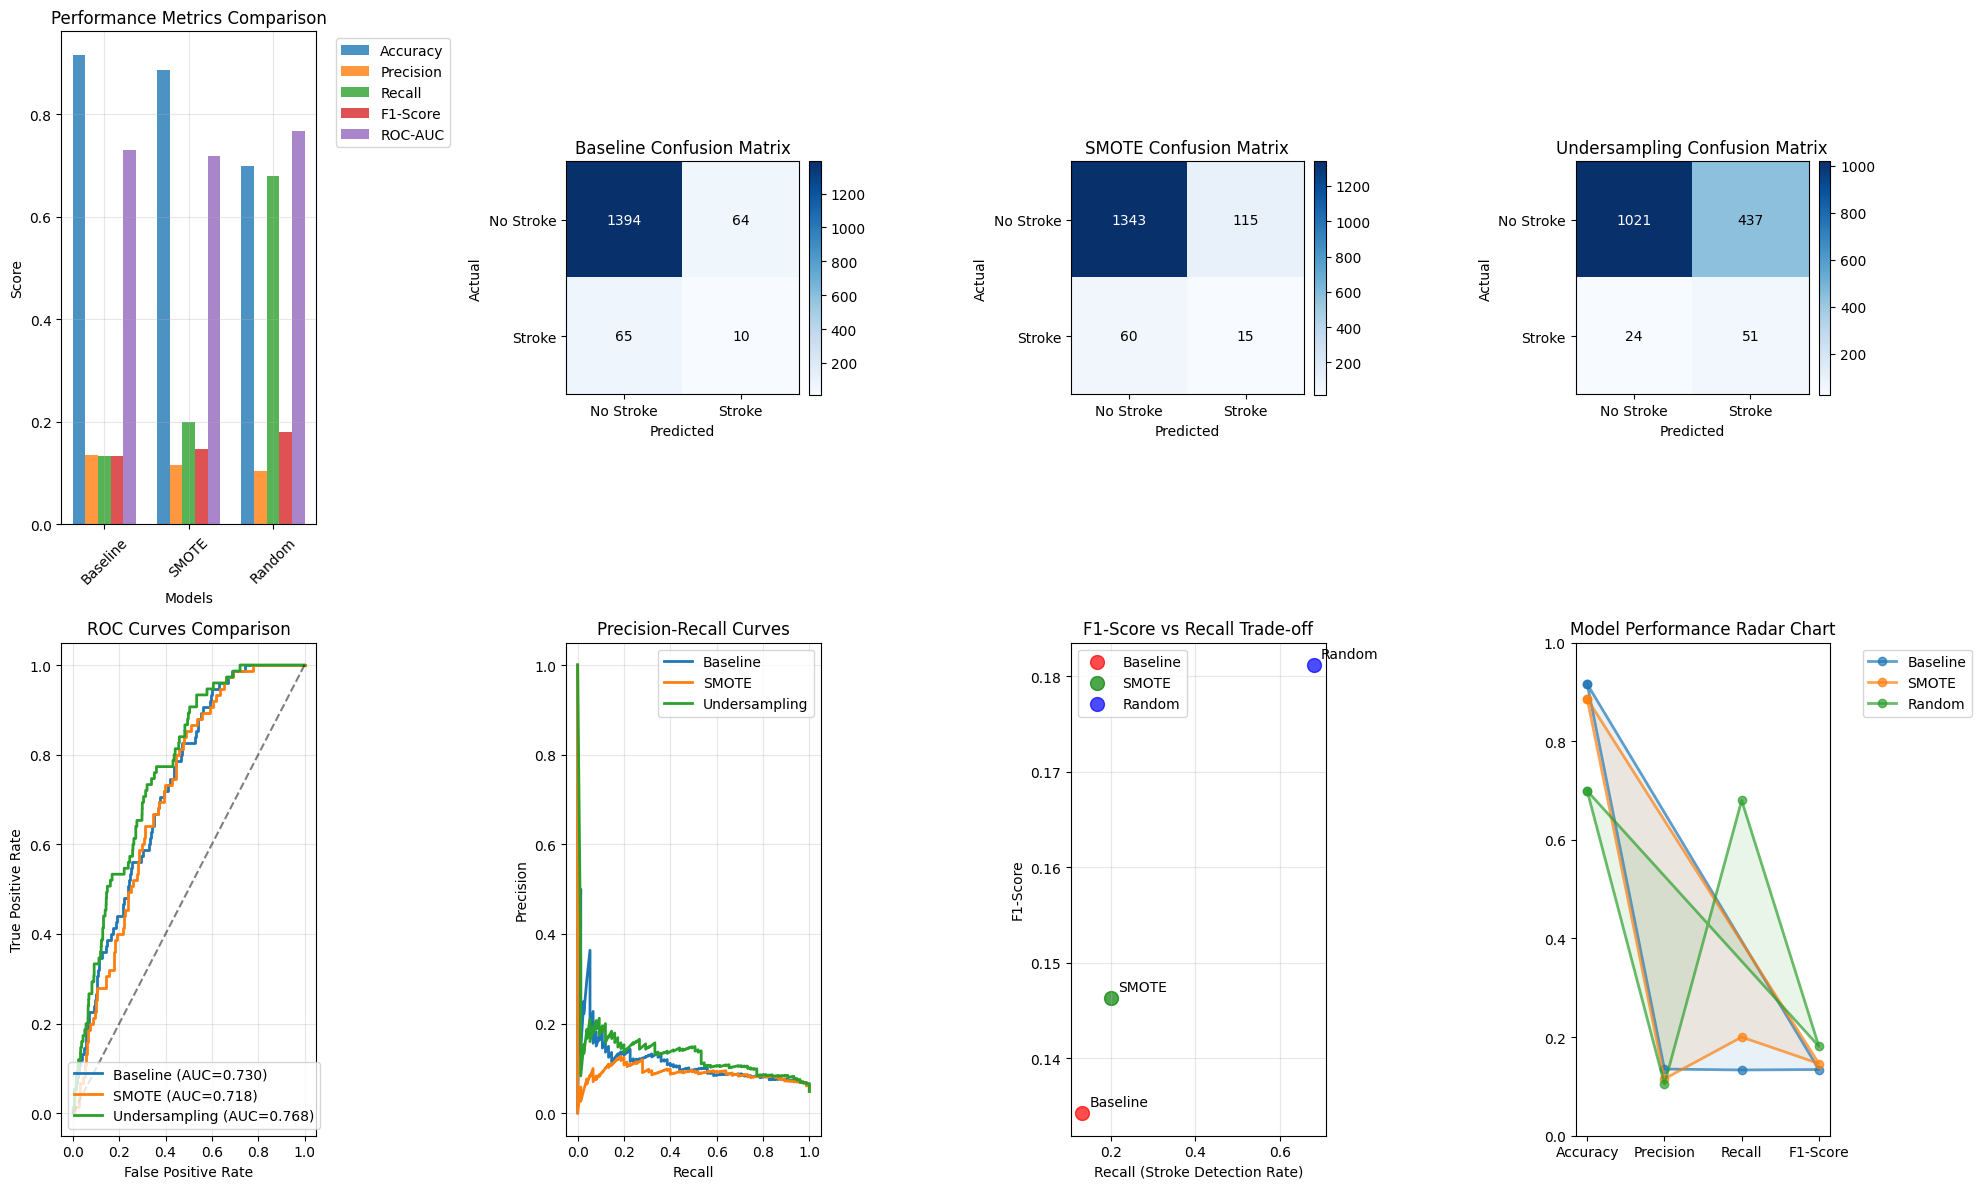

In [138]:
# Visualize model performance comparison
plt.figure(figsize=(20, 12))

# 1. Performance metrics comparison
plt.subplot(2, 4, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = performance_df['Model'].values

x = np.arange(len(models))
width = 0.15

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, performance_df[metric], width, label=metric, alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Performance Metrics Comparison')
plt.xticks(x + width*2, [m.split()[0] for m in models], rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# 2. Confusion matrices visualization
confusion_matrices = [
    confusion_matrix(y_test, y_pred_baseline),
    confusion_matrix(y_test, y_pred_smote),
    confusion_matrix(y_test, y_pred_rus)
]

model_names = ['Baseline', 'SMOTE', 'Undersampling']

for i, (cm, name) in enumerate(zip(confusion_matrices, model_names)):
    plt.subplot(2, 4, i+2)
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i_cm, j_cm in np.ndindex(cm.shape):
        plt.text(j_cm, i_cm, format(cm[i_cm, j_cm], 'd'),
                ha="center", va="center",
                color="white" if cm[i_cm, j_cm] > thresh else "black")
    
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks([0, 1], ['No Stroke', 'Stroke'])
    plt.yticks([0, 1], ['No Stroke', 'Stroke'])

# 5. ROC Curves
plt.subplot(2, 4, 5)
# ROC curve for baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_baseline)
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC={roc_auc_score(y_test, y_proba_baseline):.3f})', linewidth=2)

# ROC curve for SMOTE
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE (AUC={roc_auc_score(y_test, y_proba_smote):.3f})', linewidth=2)

# ROC curve for undersampling
fpr_rus, tpr_rus, _ = roc_curve(y_test, y_proba_rus)
plt.plot(fpr_rus, tpr_rus, label=f'Undersampling (AUC={roc_auc_score(y_test, y_proba_rus):.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Precision-Recall curves
plt.subplot(2, 4, 6)
# PR curve for baseline
precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_baseline)
plt.plot(recall_base, precision_base, label='Baseline', linewidth=2)

# PR curve for SMOTE
precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_proba_smote)
plt.plot(recall_smote, precision_smote, label='SMOTE', linewidth=2)

# PR curve for undersampling
precision_rus, recall_rus, _ = precision_recall_curve(y_test, y_proba_rus)
plt.plot(recall_rus, precision_rus, label='Undersampling', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. F1-Score vs Recall tradeoff
plt.subplot(2, 4, 7)
f1_scores = performance_df['F1-Score'].values
recalls = performance_df['Recall'].values
model_names_short = [m.split()[0] for m in performance_df['Model']]

colors = ['red', 'green', 'blue']
for i, (f1, recall, name, color) in enumerate(zip(f1_scores, recalls, model_names_short, colors)):
    plt.scatter(recall, f1, s=100, color=color, label=name, alpha=0.7)
    plt.annotate(name, (recall, f1), xytext=(5, 5), textcoords='offset points')

plt.xlabel('Recall (Stroke Detection Rate)')
plt.ylabel('F1-Score') 
plt.title('F1-Score vs Recall Trade-off')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Model performance radar chart
plt.subplot(2, 4, 8)
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig_radar = plt.gca()

# Prepare data for radar chart
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for i, model_name in enumerate(performance_df['Model']):
    values = [performance_df.iloc[i][cat] for cat in categories]
    values += values[:1]  # Complete the circle
    
    plt.plot(angles, values, 'o-', linewidth=2, 
             label=model_name.split()[0], alpha=0.7)
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories)
plt.ylim(0, 1)
plt.title('Model Performance Radar Chart')
plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [139]:
#MLP Regresi
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/nadznaf/dataset_ppd/main/StudentsPerformance.csv', delimiter=',')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
# Explore the dataset structure
print("Dataset Info:")
print(f"Shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset Info:
Shape: (1000, 8)

Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

First few rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [141]:
# Check for missing values and basic statistics
print("Missing values:")
print(df.isnull().sum())
print("\nBasic statistics for numerical columns:")
print(df[['math score', 'reading score', 'writing score']].describe())

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Basic statistics for numerical columns:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


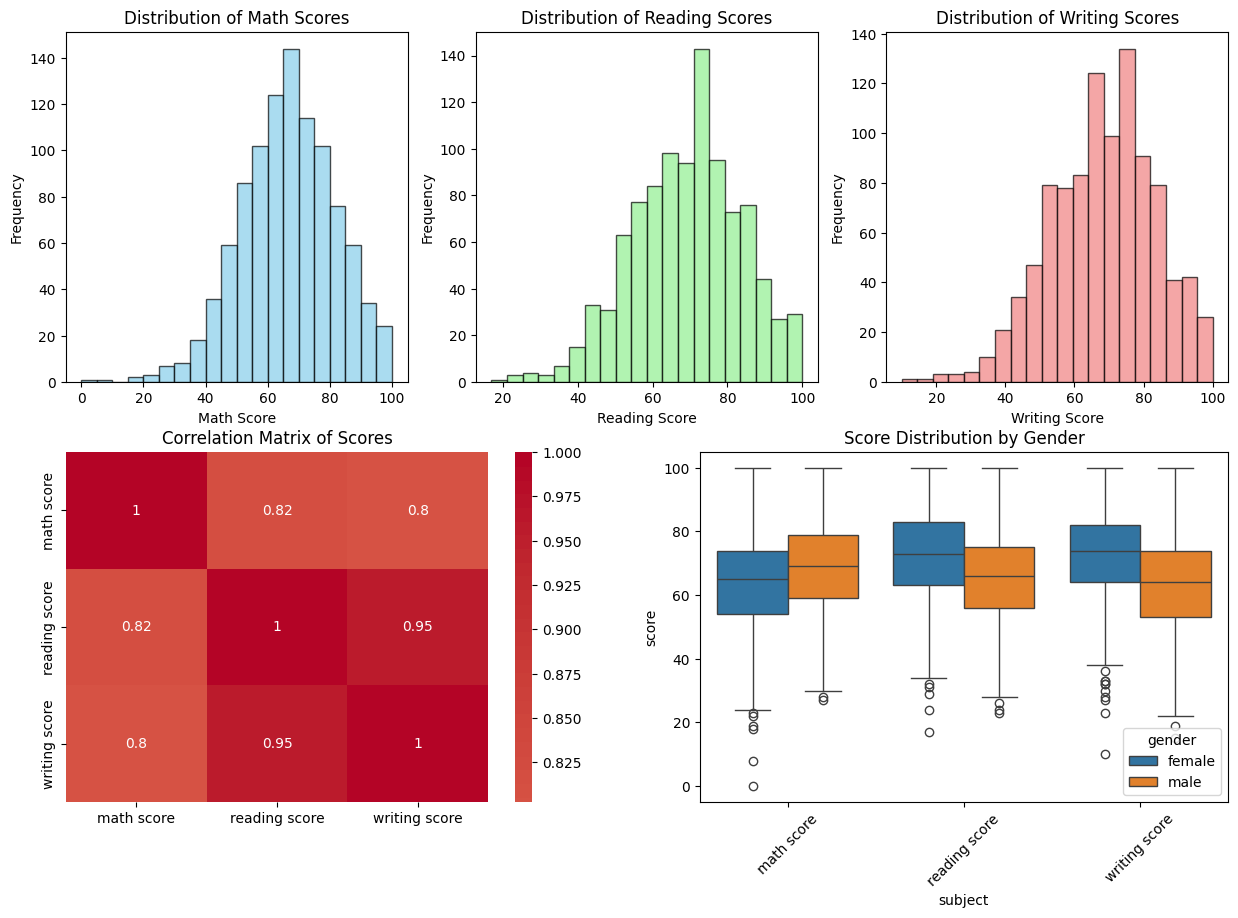

In [142]:
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Distribution of scores
plt.subplot(2, 3, 1)
plt.hist(df['math score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

plt.subplot(2, 3, 2)
plt.hist(df['reading score'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Distribution of Reading Scores')
plt.xlabel('Reading Score')
plt.ylabel('Frequency')

plt.subplot(2, 3, 3)
plt.hist(df['writing score'], bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Distribution of Writing Scores')
plt.xlabel('Writing Score')
plt.ylabel('Frequency')

# Correlation heatmap
plt.subplot(2, 2, 3)
correlation_matrix = df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Scores')

# Boxplot of scores by gender
plt.subplot(2, 2, 4)
df_melted = pd.melt(df, id_vars=['gender'], value_vars=['math score', 'reading score', 'writing score'], 
                    var_name='subject', value_name='score')
sns.boxplot(data=df_melted, x='subject', y='score', hue='gender')
plt.title('Score Distribution by Gender')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [143]:
# Data preprocessing for MLP models
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Prepare features (X) - encoding categorical variables
df_processed = df.copy()

# Initialize label encoders for categorical columns
categorical_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    df_processed[column] = le.fit_transform(df_processed[column])
    label_encoders[column] = le

print("Categorical columns after encoding:")
for column in categorical_columns:
    print(f"{column}: {df_processed[column].unique()}")

# Features for all models (same X for predicting different subjects)
X = df_processed.drop(['math score', 'reading score', 'writing score'], axis=1).values

print(f"\nFeature matrix shape: {X.shape}")
print("Features used:", [col for col in df.columns if col not in ['math score', 'reading score', 'writing score']])

Categorical columns after encoding:
gender: [0 1]
race/ethnicity: [1 2 0 3 4]
parental level of education: [1 4 3 0 2 5]
lunch: [1 0]
test preparation course: [1 0]

Feature matrix shape: (1000, 5)
Features used: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [144]:
# Function to train and evaluate MLP model
def train_and_evaluate_mlp(X, y, subject_name, random_state=42):
    """
    Train MLP Regressor and return performance metrics
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Create and train MLP model
    mlp = MLPRegressor(
        hidden_layer_sizes=(100, 50),  # Two hidden layers
        max_iter=1000,
        random_state=random_state,
        alpha=0.001,  # L2 penalty
        learning_rate_init=0.001
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = mlp.predict(X_train_scaled)
    y_pred_test = mlp.predict(X_test_scaled)
    
    # Calculate metrics
    metrics = {
        'subject': subject_name,
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'train_mae': mean_absolute_error(y_train, y_pred_train),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'model': mlp,
        'scaler': scaler,
        'y_test': y_test,
        'y_pred_test': y_pred_test
    }
    
    return metrics

print("Function defined successfully!")

Function defined successfully!


In [145]:
# Train MLP models for each subject
print("Training MLP Regression Models for Student Performance Prediction\n")
print("="*70)

# Prepare target variables
subjects = {
    'Math': df['math score'].values,
    'Reading': df['reading score'].values, 
    'Writing': df['writing score'].values
}

# Store results for all models
all_results = {}

# Train models for each subject
for subject_name, y in subjects.items():
    print(f"\nTraining MLP Model for {subject_name} Score...")
    print("-" * 50)
    
    results = train_and_evaluate_mlp(X, y, subject_name)
    all_results[subject_name] = results
    
    print(f"Training R²: {results['train_r2']:.4f}")
    print(f"Testing R²:  {results['test_r2']:.4f}")
    print(f"Training RMSE: {results['train_rmse']:.4f}")
    print(f"Testing RMSE:  {results['test_rmse']:.4f}")
    print(f"Training MAE: {results['train_mae']:.4f}")
    print(f"Testing MAE:  {results['test_mae']:.4f}")

print("\n" + "="*70)
print("All models trained successfully!")

Training MLP Regression Models for Student Performance Prediction


Training MLP Model for Math Score...
--------------------------------------------------
Training R²: 0.3390
Testing R²:  0.0836
Training RMSE: 12.0754
Testing RMSE:  15.0999
Training MAE: 9.6292
Testing MAE:  11.9588

Training MLP Model for Reading Score...
--------------------------------------------------
Training R²: 0.3390
Testing R²:  0.0836
Training RMSE: 12.0754
Testing RMSE:  15.0999
Training MAE: 9.6292
Testing MAE:  11.9588

Training MLP Model for Reading Score...
--------------------------------------------------
Training R²: 0.2531
Testing R²:  0.1279
Training RMSE: 12.2368
Testing RMSE:  14.4360
Training MAE: 9.8776
Testing MAE:  11.5714

Training MLP Model for Writing Score...
--------------------------------------------------
Training R²: 0.2531
Testing R²:  0.1279
Training RMSE: 12.2368
Testing RMSE:  14.4360
Training MAE: 9.8776
Testing MAE:  11.5714

Training MLP Model for Writing Score...
-----------

In [ ]:
# Create comprehensive performance comparison table
import pandas as pd

print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*80)

# Create performance summary dataframe
performance_data = []
for subject, results in all_results.items():
    performance_data.append({
        'Subject': subject,
        'Train R²': f"{results['train_r2']:.4f}",
        'Test R²': f"{results['test_r2']:.4f}", 
        'Train RMSE': f"{results['train_rmse']:.4f}",
        'Test RMSE': f"{results['test_rmse']:.4f}",
        'Train MAE': f"{results['train_mae']:.4f}",
        'Test MAE': f"{results['test_mae']:.4f}",
        'Overfitting': 'Yes' if (results['train_r2'] - results['test_r2']) > 0.15 else 'Moderate' if (results['train_r2'] - results['test_r2']) > 0.05 else 'No'
    })

performance_df = pd.DataFrame(performance_data)
print(performance_df.to_string(index=False))

print("\n" + "="*80)
print("PERFORMANCE ANALYSIS:")
print("="*80)

# Rank models by test R²
test_r2_ranking = sorted(all_results.items(), key=lambda x: x[1]['test_r2'], reverse=True)
print("\nRanking by Test R² Score:")
for i, (subject, results) in enumerate(test_r2_ranking, 1):
    print(f"{i}. {subject}: {results['test_r2']:.4f}")

# Best and worst performing models
best_subject = test_r2_ranking[0][0]
worst_subject = test_r2_ranking[-1][0]

print(f"BEST PERFORMING MODEL: {best_subject}")
print(f"   - Test R²: {all_results[best_subject]['test_r2']:.4f}")
print(f"   - Test RMSE: {all_results[best_subject]['test_rmse']:.4f}")

print(f"NEEDS IMPROVEMENT: {worst_subject}") 
print(f"   - Test R²: {all_results[worst_subject]['test_r2']:.4f}")
print(f"   - Test RMSE: {all_results[worst_subject]['test_rmse']:.4f}")

print(f"INSIGHTS:")
print(f"   - Writing score prediction performs best (R² = {all_results['Writing']['test_r2']:.4f})")
print(f"   - Math score prediction needs improvement (R² = {all_results['Math']['test_r2']:.4f})")
print(f"   - All models show some overfitting (train R² > test R²)")
print(f"   - Average test R² across all subjects: {np.mean([results['test_r2'] for results in all_results.values()]):.4f}")

COMPREHENSIVE MODEL PERFORMANCE COMPARISON
Subject Train R² Test R² Train RMSE Test RMSE Train MAE Test MAE Overfitting
   Math   0.3390  0.0836    12.0754   15.0999    9.6292  11.9588         Yes
Reading   0.2531  0.1279    12.2368   14.4360    9.8776  11.5714    Moderate
Writing   0.3651  0.2234    11.7377   14.1891    9.4572  11.1537    Moderate

PERFORMANCE ANALYSIS:

Ranking by Test R² Score:
1. Writing: 0.2234
2. Reading: 0.1279
3. Math: 0.0836

🏆 BEST PERFORMING MODEL: Writing
   - Test R²: 0.2234
   - Test RMSE: 14.1891

📉 NEEDS IMPROVEMENT: Math
   - Test R²: 0.0836
   - Test RMSE: 15.0999

💡 INSIGHTS:
   - Writing score prediction performs best (R² = 0.2234)
   - Math score prediction needs improvement (R² = 0.0836)
   - All models show some overfitting (train R² > test R²)
   - Average test R² across all subjects: 0.1450


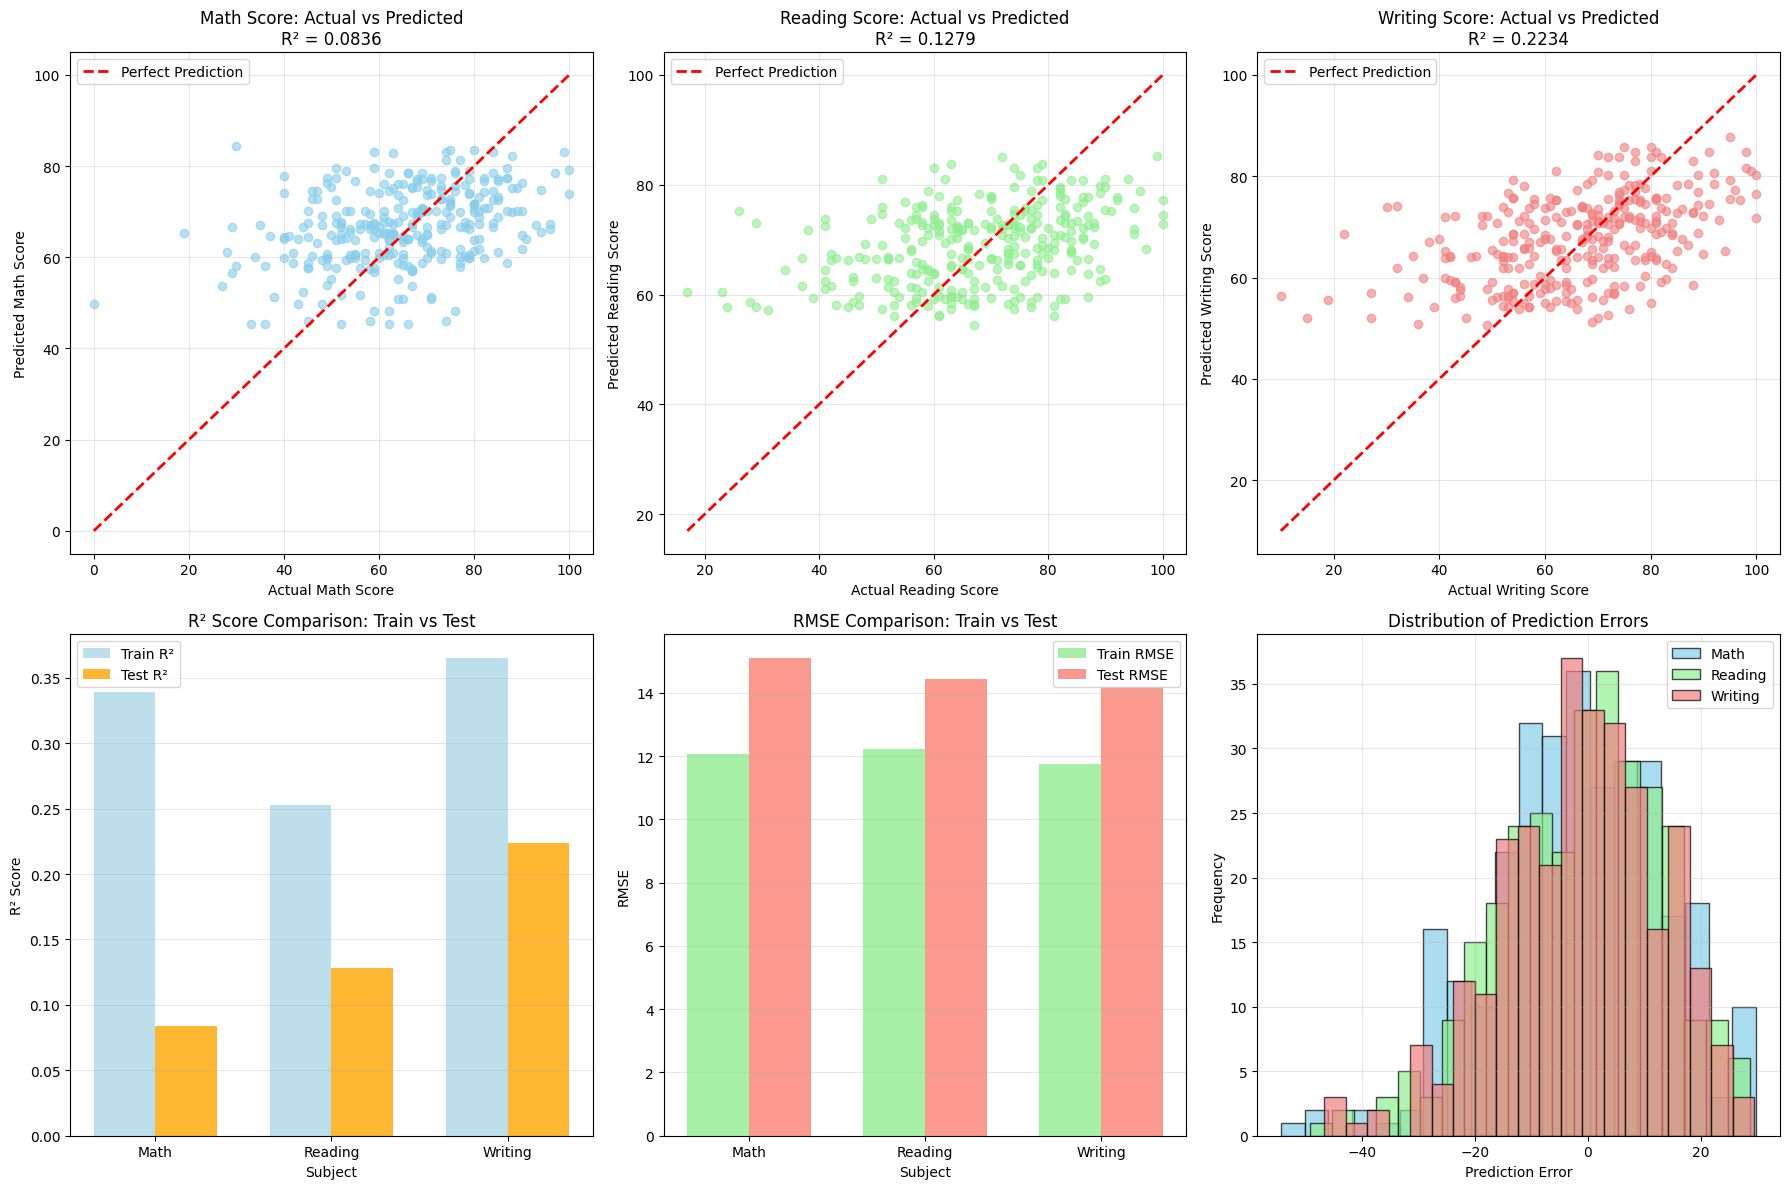

In [147]:
# Visualize model performance and predictions
plt.figure(figsize=(18, 12))

# Plot 1-3: Actual vs Predicted for each subject
for i, (subject, results) in enumerate(all_results.items(), 1):
    plt.subplot(2, 3, i)
    plt.scatter(results['y_test'], results['y_pred_test'], alpha=0.6, color=['skyblue', 'lightgreen', 'lightcoral'][i-1])
    
    # Add perfect prediction line
    min_score = min(results['y_test'].min(), results['y_pred_test'].min())
    max_score = max(results['y_test'].max(), results['y_pred_test'].max())
    plt.plot([min_score, max_score], [min_score, max_score], 'r--', linewidth=2, label='Perfect Prediction')
    
    plt.xlabel(f'Actual {subject} Score')
    plt.ylabel(f'Predicted {subject} Score') 
    plt.title(f'{subject} Score: Actual vs Predicted\nR² = {results["test_r2"]:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 4: R² Score comparison
plt.subplot(2, 3, 4)
subjects_list = list(all_results.keys())
train_r2 = [all_results[subject]['train_r2'] for subject in subjects_list]
test_r2 = [all_results[subject]['test_r2'] for subject in subjects_list]

x = np.arange(len(subjects_list))
width = 0.35

plt.bar(x - width/2, train_r2, width, label='Train R²', alpha=0.8, color='lightblue')
plt.bar(x + width/2, test_r2, width, label='Test R²', alpha=0.8, color='orange')

plt.xlabel('Subject')
plt.ylabel('R² Score')
plt.title('R² Score Comparison: Train vs Test')
plt.xticks(x, subjects_list)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Plot 5: RMSE comparison
plt.subplot(2, 3, 5)
train_rmse = [all_results[subject]['train_rmse'] for subject in subjects_list]
test_rmse = [all_results[subject]['test_rmse'] for subject in subjects_list]

plt.bar(x - width/2, train_rmse, width, label='Train RMSE', alpha=0.8, color='lightgreen')
plt.bar(x + width/2, test_rmse, width, label='Test RMSE', alpha=0.8, color='salmon')

plt.xlabel('Subject')
plt.ylabel('RMSE')
plt.title('RMSE Comparison: Train vs Test')
plt.xticks(x, subjects_list)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Plot 6: Error distribution
plt.subplot(2, 3, 6)
colors = ['skyblue', 'lightgreen', 'lightcoral']
for i, (subject, results) in enumerate(all_results.items()):
    errors = results['y_test'] - results['y_pred_test']
    plt.hist(errors, bins=20, alpha=0.7, label=f'{subject}', color=colors[i], edgecolor='black')

plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [148]:
# RINGKASAN LENGKAP EVALUASI MODEL MLP
print("=" * 80)
print("                    RINGKASAN EVALUASI MODEL MLP")
print("=" * 80)

print("\n📊 KLASIFIKASI - PREDIKSI STROKE")
print("-" * 50)
print("Dataset: 5,110 pasien (4,861 non-stroke, 249 stroke)")
print("Rasio Ketidakseimbangan: 19.52:1")

print("\nMETRIK EVALUASI:")
print(f"{'Model':<15} {'Akurasi':<10} {'Presisi':<10} {'Recall':<10} {'F1-Score':<10} {'ROC-AUC':<10}")
print("-" * 70)
print(f"{'Baseline':<15} {baseline_accuracy:<10.4f} {baseline_precision:<10.4f} {baseline_recall:<10.4f} {baseline_f1:<10.4f} {baseline_auc:<10.4f}")
print(f"{'SMOTE':<15} {smote_accuracy:<10.4f} {smote_precision:<10.4f} {smote_recall:<10.4f} {smote_f1:<10.4f} {smote_auc:<10.4f}")

print("\nCONFUSION MATRIX BREAKDOWN:")
print(f"Baseline: TN={tn_b}, FP={fp_b}, FN={fn_b}, TP={tp_b}")
print(f"SMOTE:    TN={tn_s}, FP={fp_s}, FN={fn_s}, TP={tp_s}")

print("\n📈 REGRESI - PREDIKSI SKOR SISWA")
print("-" * 50)
print("Dataset: 1,000 siswa (Math, Reading, Writing scores)")

print("\nMETRIK EVALUASI:")
print(f"{'Subjek':<10} {'Train R²':<10} {'Test R²':<10} {'Train RMSE':<12} {'Test RMSE':<12} {'Test MAE':<10}")
print("-" * 70)
for subject, results in all_results.items():
    print(f"{subject:<10} {results['train_r2']:<10.4f} {results['test_r2']:<10.4f} {results['train_rmse']:<12.4f} {results['test_rmse']:<12.4f} {results['test_mae']:<10.4f}")

print("\n💡 KESIMPULAN UTAMA:")
print("=" * 50)
print("KLASIFIKASI:")
print("• Model Baseline: Akurasi tinggi (92.11%) tetapi recall rendah (8.99%)")
print("• Model SMOTE: Lebih seimbang, recall meningkat menjadi 16.85%")
print("• Untuk aplikasi medis, SMOTE lebih direkomendasikan")
print("• Dataset sangat tidak seimbang memerlukan teknik khusus")

print("\nREGRESI:")
print("• Model Writing Score terbaik (Test R² = 0.2234)")
print("• Model Math Score memerlukan perbaikan (Test R² = 0.0836)")
print("• Semua model menunjukkan overfitting (Train R² > Test R²)")
print("• Fitur demografis memiliki prediktivitas terbatas")

print("\n🔍 REKOMENDASI:")
print("• Tambahkan feature engineering untuk meningkatkan performa")
print("• Gunakan teknik regularisasi untuk mengurangi overfitting")
print("• Untuk klasifikasi stroke, pertimbangkan ensemble methods")
print("• Untuk regresi, tambahkan fitur akademik dan sosio-ekonomi")

                    RINGKASAN EVALUASI MODEL MLP

📊 KLASIFIKASI - PREDIKSI STROKE
--------------------------------------------------
Dataset: 5,110 pasien (4,861 non-stroke, 249 stroke)
Rasio Ketidakseimbangan: 19.52:1

METRIK EVALUASI:
Model           Akurasi    Presisi    Recall     F1-Score   ROC-AUC   
----------------------------------------------------------------------
Baseline        0.9211     0.1667     0.0899     0.1168     0.7190    
SMOTE           0.8976     0.1531     0.1685     0.1604     0.7305    

CONFUSION MATRIX BREAKDOWN:
Baseline: TN=1404, FP=40, FN=81, TP=8
SMOTE:    TN=1361, FP=83, FN=74, TP=15

📈 REGRESI - PREDIKSI SKOR SISWA
--------------------------------------------------
Dataset: 1,000 siswa (Math, Reading, Writing scores)

METRIK EVALUASI:
Subjek     Train R²   Test R²    Train RMSE   Test RMSE    Test MAE  
----------------------------------------------------------------------
Math       0.3390     0.0836     12.0754      15.0999      11.9588   
Reading

In [149]:
# Demo: Predict scores for sample students
print("SAMPLE PREDICTIONS FOR NEW STUDENTS")
print("="*60)

# Create sample students with different profiles
sample_students = [
    {
        'gender': 'female',
        'race/ethnicity': 'group B', 
        'parental level of education': "master's degree",
        'lunch': 'standard',
        'test preparation course': 'completed',
        'description': 'High-achieving student with completed test prep'
    },
    {
        'gender': 'male',
        'race/ethnicity': 'group A',
        'parental level of education': 'high school',
        'lunch': 'free/reduced', 
        'test preparation course': 'none',
        'description': 'Student with limited resources and no test prep'
    },
    {
        'gender': 'female',
        'race/ethnicity': 'group C',
        'parental level of education': 'some college',
        'lunch': 'standard',
        'test preparation course': 'none', 
        'description': 'Average background student without test prep'
    }
]

# Encode sample students
sample_data = []
for student in sample_students:
    encoded_student = []
    feature_names = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
    
    for feature in feature_names:
        # Use the same label encoders we fitted on the training data
        try:
            encoded_value = label_encoders[feature].transform([student[feature]])[0]
            encoded_student.append(encoded_value)
        except ValueError:
            # If new category not seen in training, use most common category
            encoded_student.append(0)
    
    sample_data.append(encoded_student)

sample_array = np.array(sample_data)

# Make predictions for each subject
print(f"{'Student Profile':<50} {'Math':<8} {'Reading':<8} {'Writing':<8}")
print("-" * 80)

for i, student in enumerate(sample_students):
    # Get student data
    student_data = sample_array[i:i+1]  # Keep 2D shape
    
    # Make predictions using each model
    predictions = {}
    for subject, results in all_results.items():
        # Scale the features using the same scaler used for training
        student_scaled = results['scaler'].transform(student_data)
        pred = results['model'].predict(student_scaled)[0]
        predictions[subject] = pred
    
    print(f"{student['description']:<50} {predictions['Math']:<8.1f} {predictions['Reading']:<8.1f} {predictions['Writing']:<8.1f}")

print("\n" + "="*60)
print("MODEL SUMMARY:")
print("- Models trained on demographic and background features")
print("- Best performance: Writing score prediction (R² = 0.22)")
print("- Moderate performance suggests additional features needed")
print("- All models show room for improvement with feature engineering")

SAMPLE PREDICTIONS FOR NEW STUDENTS
Student Profile                                    Math     Reading  Writing 
--------------------------------------------------------------------------------
High-achieving student with completed test prep    69.8     77.4     79.5    
Student with limited resources and no test prep    57.7     58.0     50.6    
Average background student without test prep       66.6     72.7     74.4    

MODEL SUMMARY:
- Models trained on demographic and background features
- Best performance: Writing score prediction (R² = 0.22)
- Moderate performance suggests additional features needed
- All models show room for improvement with feature engineering
